In [ ]:
from __future__ import annotations

import sys
import time
from pathlib import Path
from typing import Iterable

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.patches import FancyBboxPatch, Patch

HERE = Path.cwd()
if (HERE / 'src').exists():
    REPO = HERE
elif (HERE.parent / 'src').exists():
    REPO = HERE.parent
else:
    raise RuntimeError('Could not locate repo root from current working directory.')

sys.path.insert(0, str(REPO / 'src'))
sys.path.insert(0, str(REPO))

OUTPUTS = REPO / 'benchmarks' / 'mc_vs_fourier_methods' / 'outputs'
FIGURES = OUTPUTS / 'figures'
OUTPUTS.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

from foureng.iv.implied_vol import BSInputs, bs_price_from_fwd
from foureng.mc.black_scholes_mc import MCSpec, european_call_mc
from foureng.mc.heston_conditional_mc import HestonMCScheme, heston_conditional_mc_calls
from foureng.models.base import ForwardSpec
from foureng.models.bsm import BsmParams
from foureng.models.heston import HestonParams, heston_cf, heston_cumulants
from foureng.models.variance_gamma import VGParams
from foureng.pipeline import price_strip
from foureng.pricers.cos import cos_adaptive_decision, cos_auto_grid, recommended_cos_policy
from foureng.refs.paper_refs import (
    HESTON_PUBLISHED_STRIP,
    OUSV_REGRESSION_STRIP_V1,
    CGMY_REGRESSION_STRIP_V1,
    NIG_REGRESSION_STRIP_V1,
    BATES_REGRESSION_STRIP_V1,
    HESTON_KOU_REGRESSION_STRIP_V1,
    HESTON_CGMY_REGRESSION_STRIP_V1,
)
from foureng.utils.grids import COSGridPolicy, FFTGrid
from foureng.viz.columbia import apply_columbia_style, NAVY, COLUMBIA_BLUE, DARK
from benchmarks.paper_replications.fo2008_cos.params import HESTON_TABLE5_T10

apply_columbia_style()
pd.options.display.float_format = lambda x: f'{x:,.6g}'

CB_LIGHT = '#EAF4FB'
CB_SOFT = '#D7EAF5'
CB_MID = '#7FA3C7'
CB_STEEL = '#5B8FB9'
CB_DEEP = '#1F5CA6'
CB_PALETTE = [DARK, NAVY, CB_DEEP, CB_STEEL, CB_MID, COLUMBIA_BLUE]
PYFENG_LEWIS_LABEL = 'PyFENG Lewis'


def timeit_strip(fn, *args, n_repeat: int = 3, warmup: bool = True, **kwargs):
    if warmup:
        fn(*args, **kwargs)
    best_ms = float('inf')
    out = None
    for _ in range(n_repeat):
        t0 = time.perf_counter()
        out = fn(*args, **kwargs)
        best_ms = min(best_ms, (time.perf_counter() - t0) * 1e3)
    return out, best_ms


def sci(x: float) -> str:
    if pd.isna(x):
        return '--'
    return f'{x:.2e}'


def night_style(
    df: pd.DataFrame,
    *,
    caption: str | None = None,
    formats: dict[str, str | callable] | None = None,
    highlight_min: Iterable[str] | None = None,
    highlight_max: Iterable[str] | None = None,
    hide_index: bool = True,
):
    styler = df.style
    if formats:
        styler = styler.format(formats)
    if highlight_min:
        styler = styler.highlight_min(subset=list(highlight_min), color=CB_SOFT, props='color: #0B1F3A; font-weight: bold;')
    if highlight_max:
        styler = styler.highlight_max(subset=list(highlight_max), color=CB_MID, props='color: #0B1F3A; font-weight: bold;')
    styler = styler.set_properties(**{
        'background-color': DARK,
        'color': '#F8FAFC',
        'border': '1px solid #4B6FA8',
        'font-size': '11px',
    })
    styler = styler.set_table_styles([
        {'selector': 'table', 'props': [('border-collapse', 'collapse'), ('width', '100%'), ('font-family', 'Menlo, Monaco, monospace')]},
        {'selector': 'caption', 'props': [('caption-side', 'top'), ('color', NAVY), ('font-size', '13px'), ('font-weight', 'bold'), ('padding', '6px 0')]},
        {'selector': 'th', 'props': [('background-color', NAVY), ('color', '#F8FAFC'), ('border', '1px solid #4B6FA8'), ('padding', '6px 8px')]},
        {'selector': 'td', 'props': [('padding', '6px 8px')]},
        {'selector': 'tbody tr:nth-child(even)', 'props': [('background-color', '#10294B')]},
        {'selector': 'tbody tr:nth-child(odd)', 'props': [('background-color', '#0B1F3A')]},
        {'selector': 'tbody tr:hover', 'props': [('background-color', CB_DEEP)]},
    ], overwrite=False)
    if caption is not None:
        styler = styler.set_caption(caption)
    if hide_index:
        styler = styler.hide(axis='index')
    return styler


def draw_overview_diagram():
    fig, ax = plt.subplots(figsize=(12, 2.8))
    ax.axis('off')
    boxes = [
        (0.02, 0.22, 0.18, 0.56, 'Contract + model\nheld fixed per section'),
        (0.24, 0.22, 0.18, 0.56, 'Reference price\nclosed form or oracle'),
        (0.46, 0.22, 0.18, 0.56, 'Method family\nMC, FFT, PyFENG, COS'),
        (0.68, 0.22, 0.13, 0.56, 'Error\nmax abs'),
        (0.84, 0.22, 0.13, 0.56, 'Runtime\nms'),
    ]
    colors = [CB_LIGHT, CB_SOFT, COLUMBIA_BLUE, CB_MID, NAVY]
    text_colors = [DARK, DARK, DARK, DARK, '#F8FAFC']
    for (x, y, w, h, text), color, text_color in zip(boxes, colors, text_colors):
        patch = FancyBboxPatch((x, y), w, h, boxstyle='round,pad=0.02,rounding_size=0.04',
                               facecolor=color, edgecolor=NAVY, linewidth=1.6)
        ax.add_patch(patch)
        ax.text(x + w/2, y + h/2, text, ha='center', va='center', fontsize=11, color=text_color)
    for x0, x1 in [(0.20, 0.24), (0.42, 0.46), (0.64, 0.68), (0.81, 0.84)]:
        ax.annotate('', xy=(x1, 0.5), xytext=(x0, 0.5), arrowprops=dict(arrowstyle='->', lw=1.8, color=NAVY))
    ax.set_title('Notebook structure: one benchmark policy, then method-by-method diagnostics', color=NAVY, pad=10)
    fig.tight_layout()
    return fig


def heatmap(ax, pivot: pd.DataFrame, *, title: str, cmap: str, annotation: str = 'sci', cbar_label: str = '', transform: str | None = None):
    values = pivot.to_numpy(dtype=float)
    mask = np.isnan(values)
    plot_values = values.copy()
    if transform == 'log10':
        plot_values = np.where(mask, np.nan, np.log10(np.maximum(values, 1e-18)))
    elif transform == 'neglog10':
        plot_values = np.where(mask, np.nan, -np.log10(np.maximum(values, 1e-18)))
    finite = plot_values[np.isfinite(plot_values)]
    midpoint = float(np.median(finite)) if finite.size else 0.0
    im = ax.imshow(plot_values, aspect='auto', cmap=cmap)
    ax.set_xticks(np.arange(pivot.shape[1]))
    ax.set_xticklabels([str(c) for c in pivot.columns])
    ax.set_yticks(np.arange(pivot.shape[0]))
    ax.set_yticklabels([str(i) for i in pivot.index])
    ax.set_title(title)
    for i in range(values.shape[0]):
        for j in range(values.shape[1]):
            val = values[i, j]
            text = '--' if np.isnan(val) else (f'{val:.2f}' if annotation == 'float' else f'{val:.1e}')
            tone = plot_values[i, j]
            text_color = '#F8FAFC' if np.isfinite(tone) and tone >= midpoint else DARK
            ax.text(j, i, text, ha='center', va='center', color=text_color if not np.isnan(val) else '#94a3b8', fontsize=8)
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.set_ylabel(cbar_label, rotation=90)


def method_frontier(ax, df: pd.DataFrame, *, x: str, y: str, label_col: str, title: str):
    markers = {'Monte Carlo': 'o', 'Carr-Madan FFT': 's', PYFENG_LEWIS_LABEL: 'D', 'COS classic': 'P', 'COS improved': 'X'}
    colors = {'Monte Carlo': DARK, 'Carr-Madan FFT': NAVY, PYFENG_LEWIS_LABEL: COLUMBIA_BLUE, 'COS classic': CB_STEEL, 'COS improved': CB_MID}
    for label, sub in df.groupby(label_col):
        ax.plot(sub[x], sub[y], marker=markers.get(label, 'o'), label=label, color=colors.get(label, NAVY), linewidth=1.8)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('runtime (ms)')
    ax.set_ylabel('max abs error')
    ax.set_title(title)
    ax.legend(frameon=False, loc='best')

<div style="background:linear-gradient(90deg,#012169 0%,#2b4a8b 100%);
    padding:28px 36px; border-radius:10px; color:white;
    font-family:'Helvetica Neue',Helvetica,Arial,sans-serif;
    box-shadow:0 4px 16px rgba(1,33,105,0.25);">
  <div style="font-size:12px; letter-spacing:3px; color:#B9D9EB; text-transform:uppercase;">
    Columbia University · MAFN · MATH 5030 · Spring 2026
  </div>
  <h1 style="margin:6px 0 4px 0; font-weight:700; font-size:34px;">
    Fourier Methods for European Option Pricing
  </h1>
  <div style="font-size:16px; color:#e8eef7;">
    MC baseline → Carr–Madan FFT → PyFENG Lewis → COS → Junike-style adaptive truncation
  </div>
  <div style="margin-top:14px; font-size:13px; color:#B9D9EB;">
    Presentation notebook · <code style="background:rgba(255,255,255,0.12); padding:2px 6px; border-radius:4px; color:#fff;">foureng</code>
    engine · Instructor: Prof. Jaehyuk Choi
  </div>
</div>

**What you'll see.**


### Characteristic-function backbone

All methods in this notebook use the same core input: the characteristic function of the terminal log-forward return.

$$
\varphi_T(u) = \mathbb{E}^{\mathbb{Q}}\left[e^{iuX_T}\right]
$$

where:

$$
i = \sqrt{-1}
$$

$$
X_T = \log\left(\frac{S_T}{F_0}\right)
$$

and

$$
F_0 = S_0 e^{(r-q)T}.
$$

So the characteristic function used by the pricing engines is:

$$
\varphi_T(u)
=
\mathbb{E}^{\mathbb{Q}}
\left[
\exp\left(
iu \log\left(\frac{S_T}{F_0}\right)
\right)
\right].
$$

The reason this matters is that many option-pricing models have a closed-form characteristic function even when their probability density is not available in a convenient closed form. Fourier methods exploit this by recovering prices from the characteristic function instead of simulating many paths.

This notebook pits five numerical engines against published references for European option pricing:

1. **Monte Carlo** — the flexible baseline; we show its $O(n^{-1/2})$ error is a bottleneck for surfaces.
2. **Carr–Madan FFT** — the 1999 workhorse; damped-call transform on a uniform frequency grid.
3. **PyFENG Lewis** — the external Heston integral benchmark exposed through the PyFENG backend.
4. **COS (Fang–Oosterlee 2008)** — our primary pricer; spectral convergence on a cumulant-truncated interval.
5. **COS + Junike-style adaptive truncation** — a tolerance-driven widening rule that survives stability-edge cases where the FO2008 cumulant recipe fails.

At the end we run a **cross-model anomaly scan** across all ten supported models to flag regimes where one Fourier engine is surprisingly weaker than another.


## 0. Problem setup and benchmark policy

Each section uses one contract, one model, one reference source, one error metric, and one runtime metric. The comparisons only change method settings, not the benchmark itself.

In [ ]:
benchmark_policy = pd.DataFrame([
    {
        'section': 'MC vs Carr-Madan',
        'contract / model': '41-strike BSM call strip',
        'reference': 'Black-Scholes closed form',
        'error metric': 'max abs error across strip',
        'runtime metric': 'best strip runtime (ms)',
    },
    {
        'section': 'Carr-Madan vs PyFENG Lewis',
        'contract / model': 'published Heston 5-strike strip',
        'reference': 'published 15-digit Heston prices',
        'error metric': 'max abs error across strip',
        'runtime metric': 'best strip runtime (ms)',
    },
    {
        'section': 'Plain COS replication',
        'contract / model': 'same published Heston 5-strike strip',
        'reference': 'same published Heston strip',
        'error metric': 'max abs error across strip',
        'runtime metric': 'best strip runtime (ms)',
    },
    {
        'section': 'COS truncation stress test',
        'contract / model': 'FO2008 Heston ATM, T=10',
        'reference': 'FO2008 Table 5 reference price',
        'error metric': 'abs error at K=100',
        'runtime metric': 'best price runtime (ms)',
    },
    {
        'section': 'Cross-model diagnostics',
        'contract / model': 'canonical 41-strike strips by model family',
        'reference': 'closed form or high-precision oracle per model',
        'error metric': 'max abs error on canonical strip',
        'runtime metric': 'best strip runtime (ms)',
    },
])
benchmark_policy.to_csv(OUTPUTS / 'benchmark_policy.csv', index=False)
display(night_style(
    benchmark_policy,
    caption='Benchmark policy used throughout the notebook',
    hide_index=True,
))

section,contract / model,reference,error metric,runtime metric
MC vs Carr-Madan,41-strike BSM call strip,Black-Scholes closed form,max abs error across strip,best strip runtime (ms)
Carr-Madan vs PyFENG Lewis,published Heston 5-strike strip,published 15-digit Heston prices,max abs error across strip,best strip runtime (ms)
Plain COS replication,same published Heston 5-strike strip,same published Heston strip,max abs error across strip,best strip runtime (ms)
COS truncation stress test,"FO2008 Heston ATM, T=10",FO2008 Table 5 reference price,abs error at K=100,best price runtime (ms)
Cross-model diagnostics,canonical 41-strike strips by model family,closed form or high-precision oracle per model,max abs error on canonical strip,best strip runtime (ms)


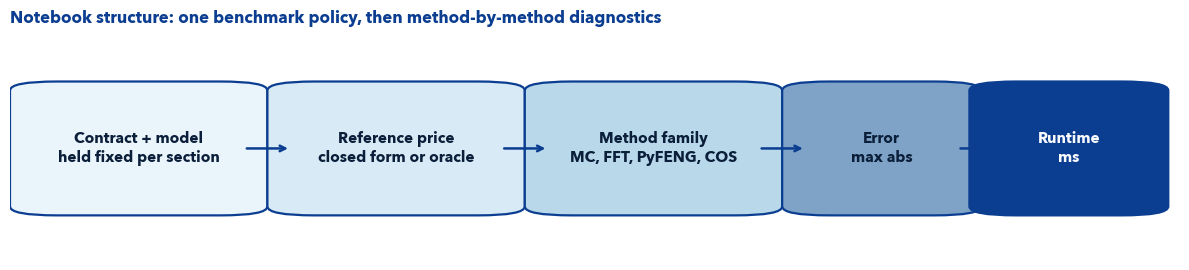

In [ ]:
fig = draw_overview_diagram()
fig.savefig(FIGURES / 'workflow_overview.png', dpi=150, bbox_inches='tight')
plt.show()

## 1. Monte Carlo baseline vs Carr-Madan

Monte Carlo is a flexible baseline, but for plain European options it can converge slowly relative to transform methods. To make that visible without changing the target, this section uses a Black-Scholes call strip and the closed-form strip price as the single source of truth for both methods.

In [ ]:
BSM_K = np.linspace(80.0, 120.0, 41)
BSM_FWD = ForwardSpec(S0=100.0, r=0.03, q=0.0, T=1.0)
BSM_PARAMS = BsmParams(sigma=0.20)
BSM_REF = np.array([
    bs_price_from_fwd(
        BSM_PARAMS.sigma,
        BSInputs(F0=BSM_FWD.F0, K=float(k), T=BSM_FWD.T, r=BSM_FWD.r, q=BSM_FWD.q, is_call=True),
    )
    for k in BSM_K
])

mc_rows = []
for n_paths in [5_000, 20_000, 50_000, 100_000, 200_000]:
    prices, runtime_ms = timeit_strip(
        european_call_mc,
        S0=BSM_FWD.S0,
        K=BSM_K,
        T=BSM_FWD.T,
        r=BSM_FWD.r,
        q=BSM_FWD.q,
        vol=BSM_PARAMS.sigma,
        mc=MCSpec(n_paths=n_paths, seed=7),
        n_repeat=2,
    )
    mc_rows.append({
        'method': 'Monte Carlo',
        'setting': f'n_paths={n_paths:,}',
        'runtime_ms': runtime_ms,
        'max_abs_err': float(np.max(np.abs(prices - BSM_REF))),
    })

cm_rows = []
for N in [256, 512, 1024, 2048, 4096]:
    prices, runtime_ms = timeit_strip(
        price_strip,
        'bsm',
        'carr_madan',
        BSM_K,
        BSM_FWD,
        BSM_PARAMS,
        grid=FFTGrid(N=N, eta=0.10, alpha=1.5),
    )
    cm_rows.append({
        'method': 'Carr-Madan FFT',
        'setting': f'N={N}, eta=0.10',
        'runtime_ms': runtime_ms,
        'max_abs_err': float(np.max(np.abs(prices - BSM_REF))),
    })

bsm_frontier = pd.DataFrame(mc_rows + cm_rows)
bsm_frontier.to_csv(OUTPUTS / 'bsm_mc_vs_carr_madan.csv', index=False)

display(night_style(
    bsm_frontier,
    caption='Black-Scholes strip: Monte Carlo vs Carr-Madan under one closed-form benchmark',
    formats={'runtime_ms': '{:.3f}', 'max_abs_err': sci},
    highlight_min=['runtime_ms', 'max_abs_err'],
))

BSM_MC_REP = european_call_mc(
    S0=BSM_FWD.S0,
    K=BSM_K,
    T=BSM_FWD.T,
    r=BSM_FWD.r,
    q=BSM_FWD.q,
    vol=BSM_PARAMS.sigma,
    mc=MCSpec(n_paths=200_000, seed=7),
)
BSM_CM_REP = price_strip('bsm', 'carr_madan', BSM_K, BSM_FWD, BSM_PARAMS, grid=FFTGrid(N=2048, eta=0.10, alpha=1.5))

method,setting,runtime_ms,max_abs_err
Monte Carlo,"n_paths=5,000",0.522,4.14e-01
Monte Carlo,"n_paths=20,000",2.675,1.76e-01
Monte Carlo,"n_paths=50,000",6.847,1.16e-01
Monte Carlo,"n_paths=100,000",11.119,4.47e-02
Monte Carlo,"n_paths=200,000",31.274,1.15e-02
Carr-Madan FFT,"N=256, eta=0.10",0.295,6.91e-02
Carr-Madan FFT,"N=512, eta=0.10",0.131,3.66e-03
Carr-Madan FFT,"N=1024, eta=0.10",0.182,1.91e-04
Carr-Madan FFT,"N=2048, eta=0.10",0.342,1.13e-05
Carr-Madan FFT,"N=4096, eta=0.10",0.973,6.92e-07


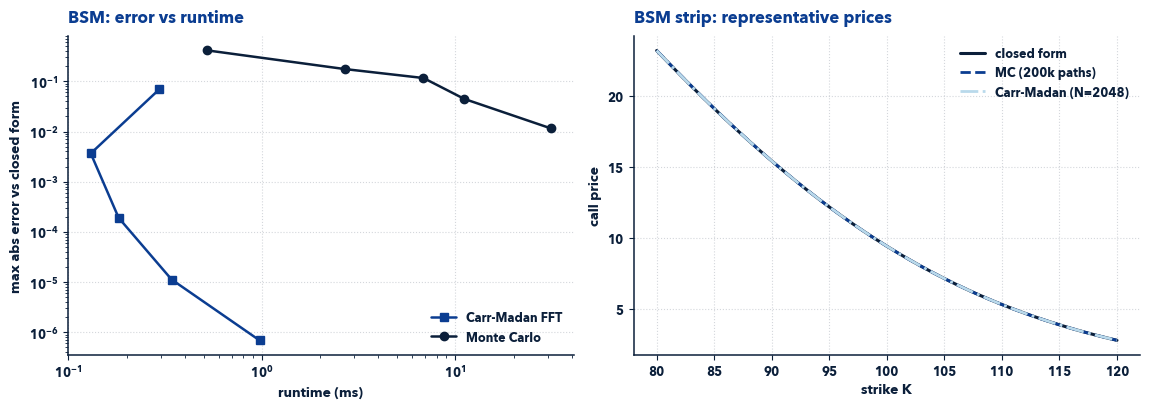

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.2))
method_frontier(axes[0], bsm_frontier, x='runtime_ms', y='max_abs_err', label_col='method', title='BSM: error vs runtime')
axes[0].set_ylabel('max abs error vs closed form')

axes[1].plot(BSM_K, BSM_REF, color=DARK, linewidth=2.2, label='closed form')
axes[1].plot(BSM_K, BSM_MC_REP, color=NAVY, linestyle='--', label='MC (200k paths)')
axes[1].plot(BSM_K, BSM_CM_REP, color=COLUMBIA_BLUE, linestyle='-.', label='Carr-Madan (N=2048)')
axes[1].set_title('BSM strip: representative prices')
axes[1].set_xlabel('strike K')
axes[1].set_ylabel('call price')
axes[1].legend(frameon=False)

fig.tight_layout()
fig.savefig(FIGURES / 'bsm_mc_vs_cm.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Carr-Madan vs PyFENG Lewis

From here on the contract and benchmark stay fixed: the published five-strike Heston strip. The implementation detail worth keeping explicit is that our dispatch key is still `pyfeng_fft`, but the wrapped PyFENG call is `HestonFft.price()`, so the external comparison leg shown below is labelled as `PyFENG Lewis`.

In [ ]:
HESTON_FWD = HESTON_PUBLISHED_STRIP.fwd
HESTON_PARAMS = HESTON_PUBLISHED_STRIP.params
HESTON_K = HESTON_PUBLISHED_STRIP.strikes
HESTON_REF = HESTON_PUBLISHED_STRIP.prices

cm_sweep_rows = []
for N in [512, 1024, 2048, 4096]:
    for eta in [0.05, 0.10, 0.25]:
        prices, runtime_ms = timeit_strip(
            price_strip,
            'heston',
            'carr_madan',
            HESTON_K,
            HESTON_FWD,
            HESTON_PARAMS,
            grid=FFTGrid(N=N, eta=eta, alpha=1.5),
        )
        cm_sweep_rows.append({
            'method': 'Carr-Madan FFT',
            'N': N,
            'aux': eta,
            'runtime_ms': runtime_ms,
            'max_abs_err': float(np.max(np.abs(prices - HESTON_REF))),
        })
cm_sweep = pd.DataFrame(cm_sweep_rows)

pyfeng_prices, pyfeng_runtime_ms = timeit_strip(
    price_strip,
    'heston',
    'pyfeng_fft',
    HESTON_K,
    HESTON_FWD,
    HESTON_PARAMS,
)

cm_best_row = cm_sweep.sort_values(['max_abs_err', 'runtime_ms']).iloc[0]
transform_summary = pd.DataFrame([
    {
        'method': 'Carr-Madan FFT',
        'configuration': f"N={int(cm_best_row['N'])}, eta={cm_best_row['aux']:.2f}",
        'runtime_ms': float(cm_best_row['runtime_ms']),
        'max_abs_err': float(cm_best_row['max_abs_err']),
    },
    {
        'method': PYFENG_LEWIS_LABEL,
        'configuration': 'repo backend default',
        'runtime_ms': pyfeng_runtime_ms,
        'max_abs_err': float(np.max(np.abs(pyfeng_prices - HESTON_REF))),
    },
])

cm_sweep.to_csv(OUTPUTS / 'heston_cm_sensitivity.csv', index=False)
transform_summary.to_csv(OUTPUTS / 'heston_transform_summary.csv', index=False)
cm_best = cm_sweep.sort_values(['max_abs_err', 'runtime_ms']).head(6).copy()
cm_best['label'] = cm_best.apply(lambda r: f"N={int(r['N'])}, eta={r['aux']:.2f}", axis=1)

display(night_style(
    transform_summary,
    caption='Heston published strip: transform comparison',
    formats={'runtime_ms': '{:.3f}', 'max_abs_err': sci},
    highlight_min=['runtime_ms', 'max_abs_err'],
))

method,configuration,runtime_ms,max_abs_err
Carr-Madan FFT,"N=4096, eta=0.10",0.510,1.08e-07
PyFENG Lewis,repo backend default,0.584,8.31e-13


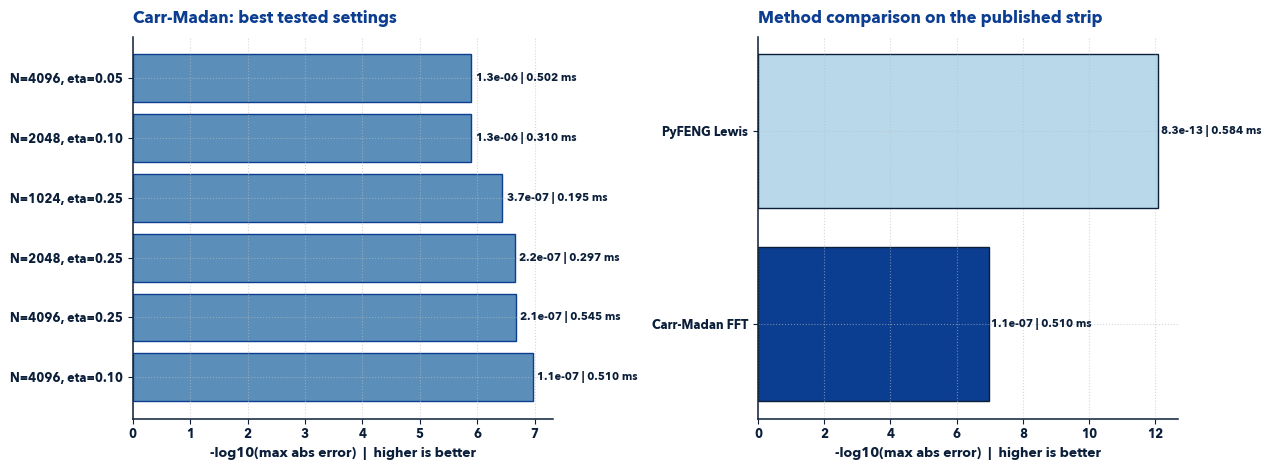

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.8))

cm_plot = cm_best.sort_values('max_abs_err', ascending=True).copy()
cm_plot['score'] = -np.log10(cm_plot['max_abs_err'])
axes[0].barh(cm_plot['label'], cm_plot['score'], color=CB_STEEL, edgecolor=NAVY)
axes[0].set_title('Carr-Madan: best tested settings')
axes[0].set_xlabel('-log10(max abs error)  |  higher is better')
for y, (_, row) in enumerate(cm_plot.iterrows()):
    axes[0].text(row['score'] + 0.08, y, f"{row['max_abs_err']:.1e} | {row['runtime_ms']:.3f} ms", va='center', fontsize=8, color=DARK)

method_compare = transform_summary.copy().sort_values('max_abs_err', ascending=False)
method_compare['score'] = -np.log10(method_compare['max_abs_err'])
axes[1].barh(method_compare['method'], method_compare['score'], color=[NAVY, COLUMBIA_BLUE], edgecolor=DARK)
axes[1].set_title('Method comparison on the published strip')
axes[1].set_xlabel('-log10(max abs error)  |  higher is better')
for y, (_, row) in enumerate(method_compare.iterrows()):
    axes[1].text(row['score'] + 0.08, y, f"{row['max_abs_err']:.1e} | {row['runtime_ms']:.3f} ms", va='center', fontsize=8, color=DARK)

fig.tight_layout()
fig.savefig(FIGURES / 'heston_transform_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()

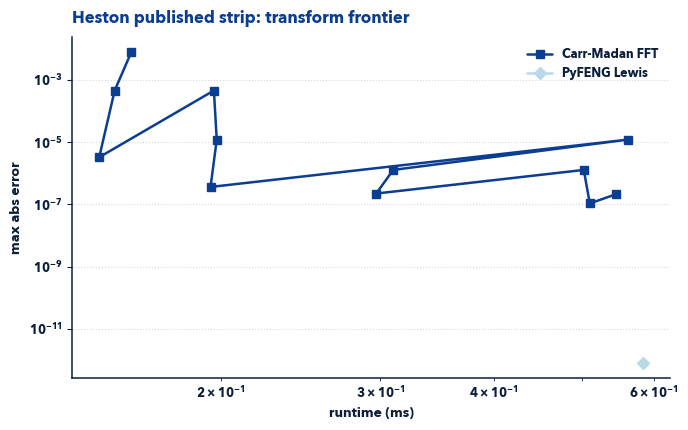

In [ ]:
frontier_transform = pd.concat([
    cm_sweep[['method', 'runtime_ms', 'max_abs_err']],
    pd.DataFrame([{
        'method': PYFENG_LEWIS_LABEL,
        'runtime_ms': pyfeng_runtime_ms,
        'max_abs_err': float(np.max(np.abs(pyfeng_prices - HESTON_REF))),
    }]),
], ignore_index=True)

fig, ax = plt.subplots(figsize=(7.0, 4.4))
method_frontier(ax, frontier_transform, x='runtime_ms', y='max_abs_err', label_col='method', title='Heston published strip: transform frontier')
fig.tight_layout()
fig.savefig(FIGURES / 'heston_transform_frontier.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Plain COS replication

This section keeps the same Heston strip and uses the plain Fang-Oosterlee setup: classical cumulant interval, fixed `L=10`, and a sweep over the cosine term count `N`. This is the baseline COS story before changing the interval policy.

In [ ]:
HESTON_CUMS = heston_cumulants(HESTON_FWD, HESTON_PARAMS)
cos_rows = []
for N in [32, 64, 128, 256, 512, 1024]:
    grid = cos_auto_grid(HESTON_CUMS, N=N, L=10.0)
    prices, runtime_ms = timeit_strip(
        price_strip,
        'heston',
        'cos',
        HESTON_K,
        HESTON_FWD,
        HESTON_PARAMS,
        grid=grid,
    )
    cos_rows.append({
        'N': N,
        'a': grid.a,
        'b': grid.b,
        'width': grid.width,
        'runtime_ms': runtime_ms,
        'max_abs_err': float(np.max(np.abs(prices - HESTON_REF))),
    })
cos_plain = pd.DataFrame(cos_rows)
cos_plain.to_csv(OUTPUTS / 'heston_cos_plain.csv', index=False)

display(night_style(
    cos_plain,
    caption='Plain COS on the published Heston strip',
    formats={'a': '{:.3f}', 'b': '{:.3f}', 'width': '{:.3f}', 'runtime_ms': '{:.3f}', 'max_abs_err': sci},
    highlight_min=['runtime_ms', 'max_abs_err'],
))

COS_STD_GRID = cos_auto_grid(HESTON_CUMS, N=256, L=10.0)
COS_STD_PRICES = price_strip('heston', 'cos', HESTON_K, HESTON_FWD, HESTON_PARAMS, grid=COS_STD_GRID)
cos_price_panel = pd.DataFrame({
    'K': HESTON_K,
    'Published ref': HESTON_REF,
    'COS N=256': COS_STD_PRICES,
    'abs err': np.abs(COS_STD_PRICES - HESTON_REF),
})
cos_price_panel.to_csv(OUTPUTS / 'heston_cos_plain_prices.csv', index=False)

N,a,b,width,runtime_ms,max_abs_err
32,-6.787,6.589,13.376,0.072,1.58e-02
64,-6.787,6.589,13.376,0.075,1.18e-05
128,-6.787,6.589,13.376,0.077,8.00e-12
256,-6.787,6.589,13.376,0.089,1.67e-12
512,-6.787,6.589,13.376,0.127,1.67e-12
1024,-6.787,6.589,13.376,0.204,1.67e-12


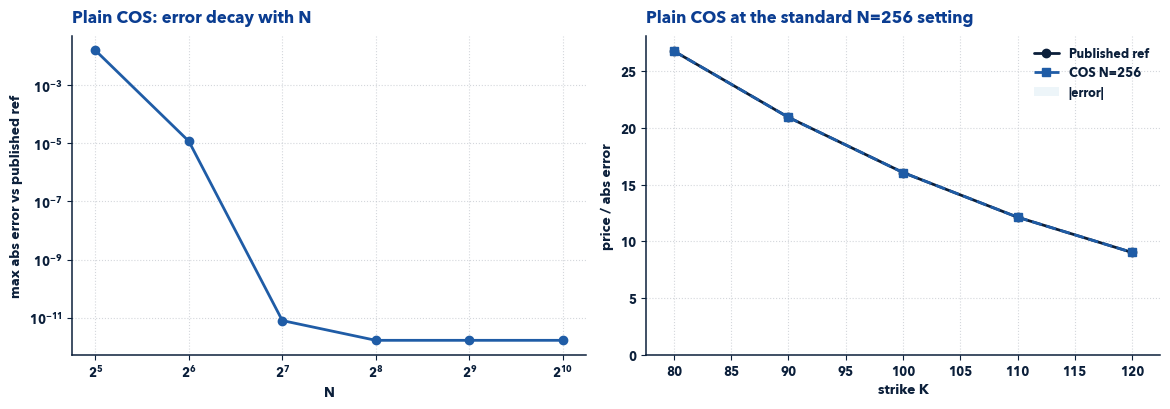

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11.8, 4.2))
axes[0].plot(cos_plain['N'], cos_plain['max_abs_err'], marker='o', color=CB_DEEP)
axes[0].set_xscale('log', base=2)
axes[0].set_yscale('log')
axes[0].set_title('Plain COS: error decay with N')
axes[0].set_xlabel('N')
axes[0].set_ylabel('max abs error vs published ref')

axes[1].plot(HESTON_K, HESTON_REF, marker='o', color=DARK, label='Published ref')
axes[1].plot(HESTON_K, COS_STD_PRICES, marker='s', linestyle='--', color=CB_DEEP, label='COS N=256')
axes[1].bar(HESTON_K, np.abs(COS_STD_PRICES - HESTON_REF), alpha=0.25, color=COLUMBIA_BLUE, label='|error|')
axes[1].set_title('Plain COS at the standard N=256 setting')
axes[1].set_xlabel('strike K')
axes[1].set_ylabel('price / abs error')
axes[1].legend(frameon=False, loc='best')

fig.tight_layout()
fig.savefig(FIGURES / 'heston_cos_plain.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. COS with improved truncation

Junike-style improvements are best read as an interval-selection layer around COS, not as a separate pricing family. To make the effect visible, this section uses the long-maturity FO2008 Heston stress case where the classical interval becomes very wide and resolution is easily wasted.

In [ ]:
CASE = HESTON_TABLE5_T10
STRESS_FWD = ForwardSpec(S0=CASE.forward, r=CASE.params['r'], q=CASE.params['q'], T=CASE.maturity)
STRESS_PARAMS = HestonParams(
    kappa=CASE.params['kappa'],
    theta=CASE.params['theta'],
    nu=CASE.params['nu'],
    rho=CASE.params['rho'],
    v0=CASE.params['v0'],
)
STRESS_K = np.asarray(CASE.strikes, dtype=float)
STRESS_REF = np.asarray([CASE.reference_values], dtype=float)
STRESS_CUMS = heston_cumulants(STRESS_FWD, STRESS_PARAMS)

stress_rows = []
for N in CASE.Ns:
    classic_grid = cos_auto_grid(STRESS_CUMS, N=N, L=CASE.extras['L'])
    classic_prices, classic_ms = timeit_strip(
        price_strip,
        'heston',
        'cos',
        STRESS_K,
        STRESS_FWD,
        STRESS_PARAMS,
        grid=classic_grid,
    )
    improved_policy = COSGridPolicy(mode='benchmark', truncation='tolerance', centered=True, fixed_N=N, eps_trunc=1e-10)
    improved_decision = cos_adaptive_decision(STRESS_CUMS, model='heston', params=STRESS_PARAMS, policy=improved_policy)
    improved_prices, improved_ms = timeit_strip(
        price_strip,
        'heston',
        'cos_improved',
        STRESS_K,
        STRESS_FWD,
        STRESS_PARAMS,
        grid=improved_policy,
    )
    stress_rows.append({
        'N': N,
        'classic_width': classic_grid.width,
        'improved_width': improved_decision.grid.width,
        'classic_runtime_ms': classic_ms,
        'improved_runtime_ms': improved_ms,
        'classic_err': float(np.max(np.abs(classic_prices - STRESS_REF))),
        'improved_err': float(np.max(np.abs(improved_prices - STRESS_REF))),
        'tail_proxy': improved_decision.tail_proxy,
        'improvement_ratio': float(np.max(np.abs(classic_prices - STRESS_REF))) / max(float(np.max(np.abs(improved_prices - STRESS_REF))), 1e-18),
    })

stress_df = pd.DataFrame(stress_rows)
stress_df.to_csv(OUTPUTS / 'heston_cos_truncation_stress.csv', index=False)
display(night_style(
    stress_df,
    caption='Long-maturity Heston stress case: classical vs improved truncation',
    formats={
        'classic_width': '{:.3f}',
        'improved_width': '{:.3f}',
        'classic_runtime_ms': '{:.3f}',
        'improved_runtime_ms': '{:.3f}',
        'classic_err': sci,
        'improved_err': sci,
        'tail_proxy': sci,
        'improvement_ratio': '{:.2f}',
    },
    highlight_min=['classic_runtime_ms', 'improved_runtime_ms', 'classic_err', 'improved_err'],
))

STRESS_CLASSIC_140 = cos_auto_grid(STRESS_CUMS, N=140, L=CASE.extras['L'])
STRESS_IMPROVED_140 = cos_adaptive_decision(
    STRESS_CUMS,
    model='heston',
    params=STRESS_PARAMS,
    policy=COSGridPolicy(mode='benchmark', truncation='tolerance', centered=True, fixed_N=140, eps_trunc=1e-10),
)

N,classic_width,improved_width,classic_runtime_ms,improved_runtime_ms,classic_err,improved_err,tail_proxy,improvement_ratio
40,70.890,17.722,0.064,0.173,3.24e+00,1.08e+01,5.33e-37,0.30
65,70.890,17.722,0.061,0.149,7.65e-01,2.54e-02,5.33e-37,30.17
90,70.890,17.722,0.061,0.139,1.54e-01,1.21e-03,5.33e-37,127.49
115,70.890,17.722,0.060,0.136,1.97e-02,9.49e-06,5.33e-37,2079.57
140,70.890,17.722,0.062,0.136,4.68e-03,6.10e-08,5.33e-37,76786.75


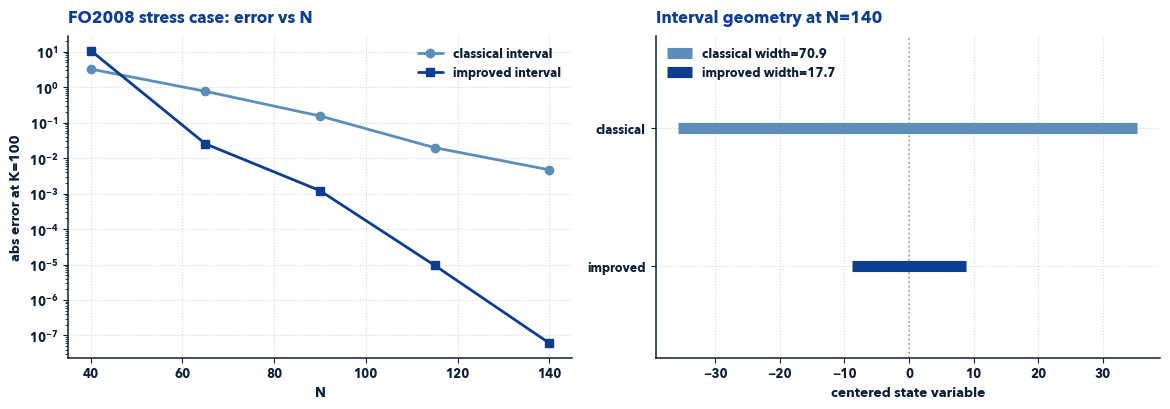

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11.8, 4.2))
axes[0].plot(stress_df['N'], stress_df['classic_err'], marker='o', color=CB_STEEL, label='classical interval')
axes[0].plot(stress_df['N'], stress_df['improved_err'], marker='s', color=NAVY, label='improved interval')
axes[0].set_yscale('log')
axes[0].set_title('FO2008 stress case: error vs N')
axes[0].set_xlabel('N')
axes[0].set_ylabel('abs error at K=100')
axes[0].legend(frameon=False)

axes[1].axvline(0.0, color='#94a3b8', linestyle=':', linewidth=1.2)
axes[1].hlines(1.0, STRESS_CLASSIC_140.a - STRESS_CLASSIC_140.center, STRESS_CLASSIC_140.b - STRESS_CLASSIC_140.center, color=CB_STEEL, linewidth=8, label=f'classical width={STRESS_CLASSIC_140.width:.1f}')
axes[1].hlines(0.4, STRESS_IMPROVED_140.grid.a, STRESS_IMPROVED_140.grid.b, color=NAVY, linewidth=8, label=f'improved width={STRESS_IMPROVED_140.grid.width:.1f}')
axes[1].set_ylim(0, 1.4)
axes[1].set_yticks([0.4, 1.0])
axes[1].set_yticklabels(['improved', 'classical'])
axes[1].set_title('Interval geometry at N=140')
axes[1].set_xlabel('centered state variable')
axes[1].legend(frameon=False, loc='upper left')

fig.tight_layout()
fig.savefig(FIGURES / 'heston_cos_truncation_stress.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Cross-model diagnostics

The final panel uses a common 41-strike strip where possible and labels which models are diffusion, stochastic-volatility, pure-jump, or hybrid jump models. The goal is not to hunt for a gimmick anomaly, but to see where the standard fixed-budget settings behave differently across model families.

In [ ]:
COMMON_K = np.linspace(80.0, 120.0, 41)
COMMON_FWD = ForwardSpec(S0=100.0, r=0.03, q=0.0, T=1.0)

cross_cases = []
# BSM closed form
bsm_params = BsmParams(sigma=0.20)
bsm_ref = np.array([
    bs_price_from_fwd(
        bsm_params.sigma,
        BSInputs(F0=COMMON_FWD.F0, K=float(k), T=COMMON_FWD.T, r=COMMON_FWD.r, q=COMMON_FWD.q, is_call=True),
    )
    for k in COMMON_K
])
cross_cases.append({
    'name': 'BSM', 'model': 'bsm', 'family': 'Diffusion', 'jumps': 'No',
    'fwd': COMMON_FWD, 'params': bsm_params, 'strikes': COMMON_K, 'ref': bsm_ref,
    'reference_source': 'Closed form', 'allow_pyfeng': True,
})
# Heston common strip
heston_params = HestonParams(kappa=2.0, theta=0.04, nu=0.3, rho=-0.7, v0=0.04)
heston_ref = price_strip('heston', 'carr_madan', COMMON_K, COMMON_FWD, heston_params, grid=FFTGrid(32768, 0.10, 1.5))
cross_cases.append({
    'name': 'Heston', 'model': 'heston', 'family': 'Stochastic vol', 'jumps': 'No',
    'fwd': COMMON_FWD, 'params': heston_params, 'strikes': COMMON_K, 'ref': heston_ref,
    'reference_source': 'CM FFT N=32768', 'allow_pyfeng': True,
})
# VG common strip
vg_params = VGParams(sigma=0.12, nu=0.2, theta=-0.14)
vg_ref = price_strip('vg', 'carr_madan', COMMON_K, COMMON_FWD, vg_params, grid=FFTGrid(32768, 0.10, 1.5))
cross_cases.append({
    'name': 'VG', 'model': 'vg', 'family': 'Pure jump', 'jumps': 'Infinite activity',
    'fwd': COMMON_FWD, 'params': vg_params, 'strikes': COMMON_K, 'ref': vg_ref,
    'reference_source': 'CM FFT N=32768', 'allow_pyfeng': True,
})
for anchor, name, family, jumps, allow_pyfeng in [
    (OUSV_REGRESSION_STRIP_V1, 'OUSV', 'Stochastic vol', 'No', True),
    (CGMY_REGRESSION_STRIP_V1, 'CGMY', 'Pure jump', 'Infinite activity', True),
    (NIG_REGRESSION_STRIP_V1, 'NIG', 'Pure jump', 'Infinite activity', True),
    (BATES_REGRESSION_STRIP_V1, 'Bates', 'SV + jumps', 'Finite activity', False),
    (HESTON_KOU_REGRESSION_STRIP_V1, 'Heston-Kou', 'SV + jumps', 'Finite activity (double-exp)', False),
    (HESTON_CGMY_REGRESSION_STRIP_V1, 'Heston-CGMY', 'SV + jumps', 'Infinite activity', False),
]:
    cross_cases.append({
        'name': name,
        'model': anchor.model,
        'family': family,
        'jumps': jumps,
        'fwd': anchor.fwd,
        'params': anchor.params,
        'strikes': anchor.strikes,
        'ref': anchor.prices,
        'reference_source': anchor.ref_method,
        'allow_pyfeng': allow_pyfeng,
    })

taxonomy = pd.DataFrame([
    {
        'model': c['name'],
        'family': c['family'],
        'jump structure': c['jumps'],
        'strip points': len(c['strikes']),
        'reference source': c['reference_source'],
    }
    for c in cross_cases
])
taxonomy.to_csv(OUTPUTS / 'cross_model_taxonomy.csv', index=False)
display(night_style(
    taxonomy,
    caption='Model taxonomy used in the cross-model diagnostic panel',
    hide_index=True,
))

cross_rows = []
for case in cross_cases:
    model = case['model']
    fwd = case['fwd']
    params = case['params']
    strikes = case['strikes']
    ref = case['ref']
    methods = [
        ('Carr-Madan FFT', lambda: price_strip(model, 'carr_madan', strikes, fwd, params, grid=FFTGrid(2048, 0.10, 1.5))),
        ('COS classic', lambda: price_strip(model, 'cos', strikes, fwd, params)),
        ('COS improved', lambda: price_strip(model, 'cos_improved', strikes, fwd, params, grid=recommended_cos_policy(model, params, mode='surface'))),
    ]
    if case['allow_pyfeng']:
        methods.append((PYFENG_LEWIS_LABEL, lambda: price_strip(model, 'pyfeng_fft', strikes, fwd, params)))
    for label, fn in methods:
        try:
            prices, runtime_ms = timeit_strip(fn, n_repeat=2)
            err = float(np.max(np.abs(np.asarray(prices) - ref)))
        except Exception:
            runtime_ms = np.nan
            err = np.nan
        cross_rows.append({
            'model': case['name'],
            'family': case['family'],
            'jumps': case['jumps'],
            'method': label,
            'runtime_ms': runtime_ms,
            'max_abs_err': err,
        })

cross_results = pd.DataFrame(cross_rows)
cross_results.to_csv(OUTPUTS / 'cross_model_results.csv', index=False)

best_rows = []
for model, sub in cross_results.groupby('model'):
    sub_valid = sub.dropna(subset=['runtime_ms', 'max_abs_err'])
    best_err = sub_valid.sort_values(['max_abs_err', 'runtime_ms']).iloc[0]
    fastest = sub_valid.sort_values(['runtime_ms', 'max_abs_err']).iloc[0]
    best_rows.append({
        'model': model,
        'best by error': best_err['method'],
        'best error': best_err['max_abs_err'],
        'fastest': fastest['method'],
        'fastest runtime_ms': fastest['runtime_ms'],
    })

best_summary = pd.DataFrame(best_rows)
best_summary.to_csv(OUTPUTS / 'cross_model_best_summary.csv', index=False)
display(night_style(
    best_summary,
    caption='Best-performing method by model under the fixed-budget settings',
    formats={'best error': sci, 'fastest runtime_ms': '{:.3f}'},
    hide_index=True,
))

model,family,jump structure,strip points,reference source
BSM,Diffusion,No,41,Closed form
Heston,Stochastic vol,No,41,CM FFT N=32768
VG,Pure jump,Infinite activity,41,CM FFT N=32768
OUSV,Stochastic vol,No,41,CM FFT N=32768 eta=0.10 alpha=1.5 (cross-verified vs FRFT N=16384 and COS N=4096 to ~1e-10)
CGMY,Pure jump,Infinite activity,41,CM FFT N=32768 eta=0.10 alpha=1.5 (cross-verified vs FRFT N=16384 and COS N=4096 to ~1e-10)
NIG,Pure jump,Infinite activity,41,CM FFT N=32768 eta=0.10 alpha=1.5 (cross-verified vs FRFT N=16384 and COS N=4096 to ~1e-10)
Bates,SV + jumps,Finite activity,41,CM FFT N=32768 eta=0.10 alpha=1.5 (cross-verified vs FRFT N=16384 and COS N=4096 to ~1e-10)
Heston-Kou,SV + jumps,Finite activity (double-exp),41,CM FFT N=32768 eta=0.10 alpha=1.5 (cross-verified vs FRFT N=16384 and COS N=4096 to ~1e-10)
Heston-CGMY,SV + jumps,Infinite activity,41,CM FFT N=32768 eta=0.10 alpha=1.5 (cross-verified vs FRFT N=16384 and COS N=4096 to ~1e-10)


model,best by error,best error,fastest,fastest runtime_ms
BSM,COS classic,2.84e-14,COS improved,0.160
Bates,COS classic,3.13e-10,COS classic,0.300
CGMY,PyFENG Lewis,5.77e-11,COS classic,0.233
Heston,PyFENG Lewis,3.82e-10,COS improved,0.174
Heston-CGMY,COS improved,3.37e-11,COS classic,0.288
Heston-Kou,COS classic,9.42e-10,COS classic,0.305
NIG,PyFENG Lewis,3.68e-10,COS improved,0.200
OUSV,PyFENG Lewis,4.11e-10,COS improved,0.242
VG,COS classic,9.56e-10,COS classic,0.217


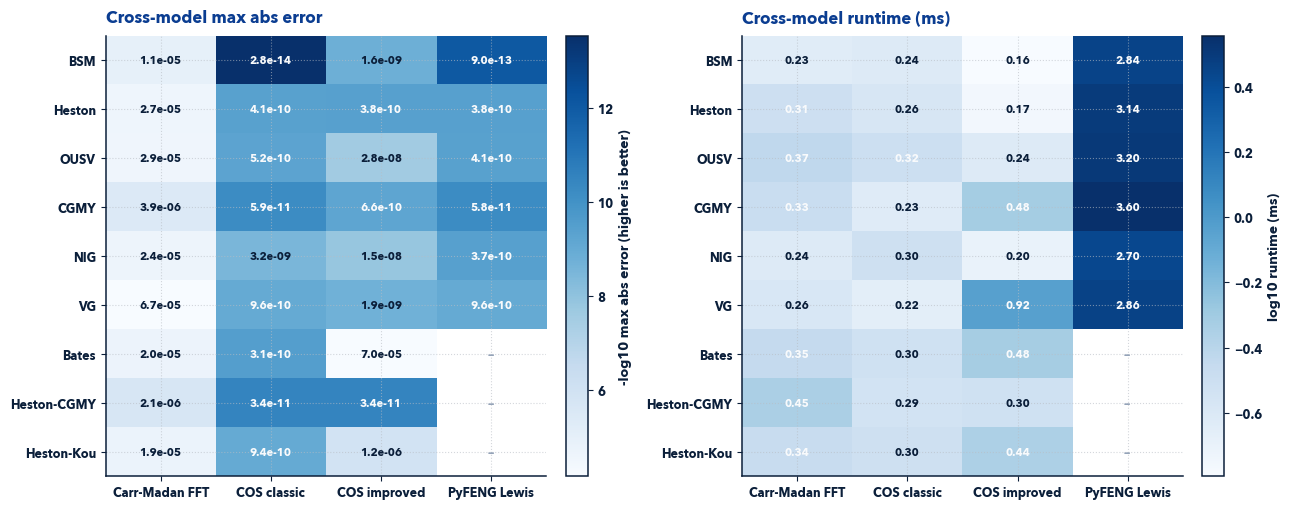

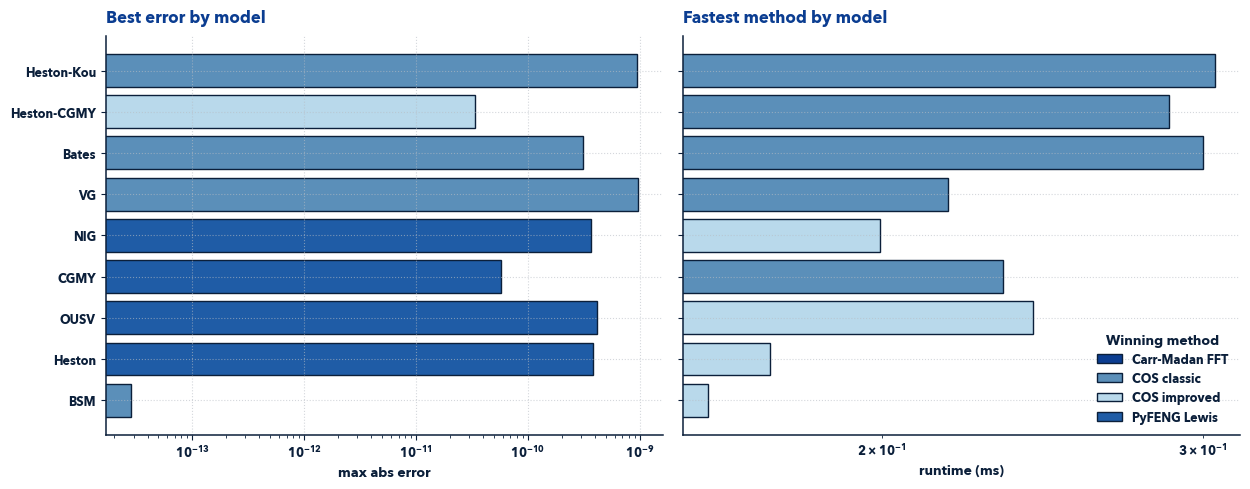

In [ ]:
family_order = ['Diffusion', 'Stochastic vol', 'Pure jump', 'SV + jumps']
model_order = (
    taxonomy.assign(_family_order=taxonomy['family'].map({name: i for i, name in enumerate(family_order)}))
    .sort_values(['_family_order', 'model'])['model']
    .tolist()
)
method_order = ['Carr-Madan FFT', 'COS classic', 'COS improved', PYFENG_LEWIS_LABEL]

error_pivot = cross_results.pivot(index='model', columns='method', values='max_abs_err').reindex(index=model_order, columns=method_order)
runtime_pivot = cross_results.pivot(index='model', columns='method', values='runtime_ms').reindex(index=model_order, columns=method_order)

fig, axes = plt.subplots(1, 2, figsize=(13.0, 5.2))
heatmap(axes[0], error_pivot, title='Cross-model max abs error', cmap='Blues', cbar_label='-log10 max abs error (higher is better)', transform='neglog10')
heatmap(axes[1], runtime_pivot, title='Cross-model runtime (ms)', cmap='Blues', cbar_label='log10 runtime (ms)', annotation='float', transform='log10')
fig.tight_layout()
fig.savefig(FIGURES / 'cross_model_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()

method_colors = {
    'Carr-Madan FFT': NAVY,
    'COS classic': CB_STEEL,
    'COS improved': COLUMBIA_BLUE,
    PYFENG_LEWIS_LABEL: CB_DEEP,
}

best_error = (
    cross_results.dropna(subset=['max_abs_err', 'runtime_ms'])
    .sort_values(['model', 'max_abs_err', 'runtime_ms'])
    .groupby('model', as_index=False)
    .first()
)
fastest_runtime = (
    cross_results.dropna(subset=['max_abs_err', 'runtime_ms'])
    .sort_values(['model', 'runtime_ms', 'max_abs_err'])
    .groupby('model', as_index=False)
    .first()
)
best_error['model'] = pd.Categorical(best_error['model'], categories=model_order, ordered=True)
fastest_runtime['model'] = pd.Categorical(fastest_runtime['model'], categories=model_order, ordered=True)
best_error = best_error.sort_values('model')
fastest_runtime = fastest_runtime.sort_values('model')

fig2, axes2 = plt.subplots(1, 2, figsize=(12.6, 5.0), sharey=True)
axes2[0].barh(best_error['model'].astype(str), best_error['max_abs_err'], color=[method_colors[m] for m in best_error['method']], edgecolor=DARK)
axes2[0].set_xscale('log')
axes2[0].set_title('Best error by model')
axes2[0].set_xlabel('max abs error')

axes2[1].barh(fastest_runtime['model'].astype(str), fastest_runtime['runtime_ms'], color=[method_colors[m] for m in fastest_runtime['method']], edgecolor=DARK)
axes2[1].set_xscale('log')
axes2[1].set_title('Fastest method by model')
axes2[1].set_xlabel('runtime (ms)')

legend_handles = [Patch(facecolor=color, edgecolor=DARK, label=label) for label, color in method_colors.items()]
axes2[1].legend(handles=legend_handles, frameon=False, loc='lower right', title='Winning method')

fig2.tight_layout()
fig2.savefig(FIGURES / 'cross_model_frontier.png', dpi=150, bbox_inches='tight')
plt.show()

## Takeaways

The notebook now reads in layers rather than as one long method dump. The Black-Scholes opening makes the MC-versus-transform tradeoff obvious against a closed-form truth, the Heston sections separate transform sensitivity from plain COS behaviour, the truncation stress test isolates the interval-selection issue, and the final sweep shows how those conclusions move once jump models and hybrid jump-volatility models enter the picture.